In [323]:
import torch
import os
import ast
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

### Log file helper functions

In [324]:
def get_config_dict(model, model_path, dataset="synthetic_res_scbm"):
    log_file = os.path.join("experiments", model, dataset, model_path, "log.txt")
    if os.path.exists(log_file):
        with open(log_file, "r") as f:
            lines = f.readlines()
            info_dict = lines[0].strip()  
            info_dict =  ast.literal_eval(info_dict)
            
        return info_dict
    else:
        raise FileNotFoundError(f"Log file not found: {log_file}")
    
def test_metrics(model, model_path, data_difficulty, dataset="synthetic_res_scbm"):
    metrics = {}
    with open(os.path.join("experiments", model, dataset, data_difficulty, model_path, "log.txt"), "r") as f:
        lines = f.readlines()
        for line in lines:
            if "Test" in line:
                test_line = line
                break
        y_accuracy = re.findall(r"y_accuracy:\s*([0-9.]+)", test_line)[0]
        c_accuracy = re.findall(r"c_accuracy:\s*([0-9.]+)", test_line)[0]
        c_auc = re.findall(r"c_AUROC:\s*([0-9.]+)", test_line)[0]
        metrics["y_accuracy"] = float(y_accuracy)
        metrics["c_accuracy"] = float(c_accuracy)
        metrics["c_auc"] = float(c_auc)
    return metrics   

def dataset_info(model, model_path, dataset="synthetic_res_scbm"):
    log_file_path = os.path.join("experiments", model, dataset, model_path, "log.txt")
    with open(log_file_path, "r") as f:
        lines = f.readlines()
        info = {}
        for line_num, line in enumerate(lines):
            if line_num == 0:
                continue
            if "Epoch" in line:
                break
            
            if ":" in line:
                key, value = line.split(":", 1)
                info[key.strip()] = value.strip()
    return info

# Used in other cells
"""
def get_data_dir_path_from_model_log(model, model_path, dataset="synthetic_res_scbm"):
    log_file_path = os.path.join("experiments", model, dataset, model_path, "log.txt")
    with open(log_file_path, "r") as f:
        lines = f.readlines()
        for line in lines:
            if line.startswith("data_dir:"):
                data_dir_line = line
                break
        data_dir = data_dir_line.split("data_dir:")[1].strip()
        data_dir = "/".join(data_dir.split("/")[-1:])
    full_datapath = os.path.join("datasets", dataset, data_dir)
    return full_datapath
"""


# New cells use this
def get_data_dir_path_from_model_log(full_model_path):
    log_file_path = os.path.join(full_model_path, "log.txt")
    data_dir_in_line = False
    loaded_data_dir_in_line = False
    with open(log_file_path, "r") as f:
        lines = f.readlines()
        for line in lines:
            if line.startswith("data_dir:"):
                data_dir_line = line
                data_dir_in_line = True
                break
            elif line.startswith("Loading existing synthetic dataset from"):
                data_dir_line = line
                loaded_data_dir_in_line = True
                break
        if data_dir_in_line:
            data_dir = data_dir_line.split("data_dir:")[1].strip()
        elif loaded_data_dir_in_line:
            data_dir = data_dir_line.split("Loading existing synthetic dataset from")[1].strip()
        data_dir = "/".join(data_dir.split("/")[-1:])

    return data_dir


### Linear model metrics helper function

In [325]:
def get_metrics_dataset_linear_model(full_model_path, dataset_difficulty, dataset="synthetic_res_scbm"):
    full_data_path = get_data_dir_path_from_model_log(full_model_path)
    data_dir_name = full_data_path.split("/")[-1]
    linear_models_dir = os.path.join("experiments", "linear_head", dataset, dataset_difficulty)
    for model_dir in os.listdir(linear_models_dir):
        model_name_start = data_dir_name + "_trueResUsed_False"
        if model_dir.startswith(model_name_start):
            linear_model_path = model_dir
            break
    with open(os.path.join(linear_models_dir, linear_model_path, "log.txt"), "r") as f:
        lines = f.readlines()
        for line in lines:
            if "Test" in line:
                test_line = line
                break
        y_accuracy = re.findall(r"Final Test Accuracy:\s*([0-9.]+)", test_line)[0]
        
    return float(y_accuracy)

### Correlation helper functions

In [326]:
def corr_matrix(A, B, eps=1e-8):
    """
    Compute the correlation matrix between two matrices A and B.
    """
    A = A.float()
    B = B.float()

    A = A - A.mean(dim=0, keepdim=True)
    B = B - B.mean(dim=0, keepdim=True)

    A = A / (A.std(dim=0, keepdim=True) + eps)
    B = B / (B.std(dim=0, keepdim=True) + eps)

    return A.T @ B / (A.shape[0] - 1)



def plot_sigma_heatmap(Sigma, obs_dim=None, labels=None, title="", xlabel="", ylabel="", vmax=None, vmin=None, figsize=(8,8), cmap="vlag"):
    # Sigma: numpy array (n,n)
    fmt=".2f"
    plt.figure(figsize=figsize)
    if vmin is None or vmax is None:
        m = np.abs(Sigma).max()
        vmin, vmax = -m, m
    if labels is None:
        labels = [f"Dim {i}" for i in range(Sigma.shape[0])]
    ax = sns.heatmap(Sigma, cmap=cmap, center=0, vmin=vmin, vmax=vmax,
                     annot=True, fmt=fmt, annot_kws={"fontsize":8},
                     xticklabels=labels, yticklabels=labels, square=True)
    
    if obs_dim is not None:
        # draw separators between observed / hidden blocks
        ax.hlines([obs_dim], *ax.get_xlim(), colors='k', linewidth=1)
        ax.vlines([obs_dim], *ax.get_ylim(), colors='k', linewidth=1)
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    return ax

### AUR-ROC

In [327]:
import numpy as np
from sklearn.metrics import roc_auc_score

def residual_mu_hidden_auc(mu_res, H_true):
    """
    mu_res: [N, R] continuous residual means
    H_true: [N, H] binary hidden concepts
    """
    if hasattr(mu_res, "detach"):
        mu_res = mu_res.detach().cpu().numpy()
    if hasattr(H_true, "detach"):
        H_true = H_true.detach().cpu().numpy()

    R = mu_res.shape[1]
    H = H_true.shape[1]

    auc = np.zeros((R, H))

    for r in range(R):
        for h in range(H):
            y = H_true[:, h]

            # Skip degenerate hidden concepts
            if len(np.unique(y)) < 2:
                auc[r, h] = np.nan
                continue

            score = mu_res[:, r]
            auc_val = roc_auc_score(y, score)

            # AUC below 0.5 means the dimension is negatively aligned.
            # Flip it so 0.9 and 0.1 both indicate strong recoverability.
            auc[r, h] = max(auc_val, 1 - auc_val)

    return auc

In [328]:
def axis_aligned_recovery(df, residual_cols, hidden_cols):
    """
    For each hidden concept h_k, find the residual dimension r_j
    that best recovers it using ROC-AUC.

    Also checks the flipped direction 1 - r_j, because a residual
    may encode absence of a hidden concept.
    """
    rows = []

    for h_col in hidden_cols:
        y = df[h_col].values.astype(int)

        for r_col in residual_cols:
            r = df[r_col].values.astype(float)

            auc_pos = roc_auc_score(y, r)
            auc_neg = roc_auc_score(y, 1.0 - r)

            if auc_pos >= auc_neg:
                best_auc = auc_pos
                direction = "positive"
            else:
                best_auc = auc_neg
                direction = "negative"

            rows.append({
                "hidden_concept": h_col,
                "residual": r_col,
                "auc_positive": auc_pos,
                "auc_negative": auc_neg,
                "best_auc": best_auc,
                "direction": direction,
            })

    result = pd.DataFrame(rows)

    best_per_hidden = (
        result
        .sort_values("best_auc", ascending=False)
        .groupby("hidden_concept")
        .head(1)
        .reset_index(drop=True)
    )

    return result, best_per_hidden

Metrics for hidden_concept_0: 0.653, AUC: 0.720, F1: 0.644


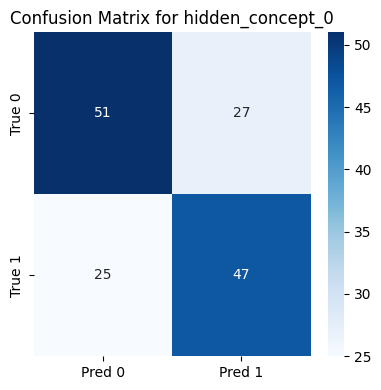

Metrics for hidden_concept_4: 0.760, AUC: 0.841, F1: 0.750


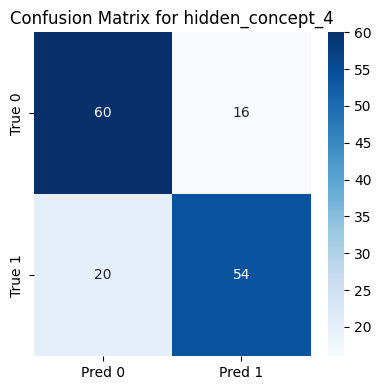

,hidden_concept,distributed_auc,distributed_accuracy,distributed_f1,num_positive,num_negative,coef_residuals_sample_mean_0,coef_residuals_sample_mean_1,coef_residuals_sample_mean_2,coef_residuals_sample_mean_3,coef_residuals_sample_mean_4
0,hidden_concept_0,0.719729,0.653333,0.643836,239,261,0.072762,0.684021,-0.007477,0.940292,-0.300160
1,hidden_concept_4,0.841127,0.760000,0.750000,246,254,-0.315430,-0.513098,-0.389758,-1.881935,-1.039945


In [329]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score


def distributed_recovery(
    df,
    residual_cols=None,
    hidden_cols=None,
    test_size=0.3,
    random_state=0,
):
    """
    Predict each hidden concept from the full residual vector.

    This tests whether hidden concept information is distributed across
    multiple residual dimensions.

    Args:
        df: dataframe containing residual mean columns and hidden concept columns.
        residual_cols: list of residual mean column names.
        hidden_cols: list of hidden concept column names.
        test_size: fraction used for test set.
        random_state: seed.

    Returns:
        DataFrame with AUC, accuracy, F1, and logistic-regression coefficients.
    """

    if residual_cols is None:
        residual_cols = [
            c for c in df.columns
            if "residuals_sample_mean" in c
        ]

    if hidden_cols is None:
        hidden_cols = [
            c for c in df.columns
            if "hidden_concept" in c
        ]

    X = df[residual_cols].values.astype(float)

    rows = []

    for h_col in hidden_cols:
        y = df[h_col].values.astype(int)

        # Skip degenerate hidden concepts
        if len(np.unique(y)) < 2:
            print(f"Skipping {h_col}: only one class present.")
            continue

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            random_state=random_state,
            stratify=y,
        )

        clf = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                random_state=random_state,
            )
        )

        clf.fit(X_train, y_train)

        y_prob = clf.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        auc = roc_auc_score(y_test, y_prob)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        # Extract logistic regression coefficients
        logreg = clf.named_steps["logisticregression"]
        coefs = logreg.coef_[0]

        coef_dict = {
            f"coef_{res_col}": coef
            for res_col, coef in zip(residual_cols, coefs)
        }

        row = {
            "hidden_concept": h_col,
            "distributed_auc": auc,
            "distributed_accuracy": acc,
            "distributed_f1": f1,
            "num_positive": int(y.sum()),
            "num_negative": int((1 - y).sum()),
        }
        
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(y_test, y_pred)
        print(f"Metrics for {h_col}: {acc:.3f}, AUC: {auc:.3f}, F1: {f1:.3f}")
        # plot nicer confusion matrix
        plt.figure(figsize=(4, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Pred 0", "Pred 1"],
                    yticklabels=["True 0", "True 1"])
        plt.title(f"Confusion Matrix for {h_col}")
        plt.tight_layout()
        plt.show()

        row.update(coef_dict)
        rows.append(row)

    return pd.DataFrame(rows)



df = pd.read_csv("experiments/scbm_residual/synthetic_res_scbm/easy/analysis_csv/alpha_1.0_beta_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_200_epochs_2026-06-04_17-42-45_ac44c/preds_sample_true_residuals.csv")


distributed_recovery(df)





In [330]:
models = [("scbm_residual", "alpha_1.0_beta_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_200_epochs_2026-06-04_17-42-45_ac44c", "easy"),
          ("scbm_residual", "alpha_1.0_beta_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_200_epochs_2026-06-04_17-42-56_a5743", "medium"),
          ("scbm_residual", "alpha_1.0_beta_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_200_epochs_2026-06-04_17-42-45_5c587", "hard"),
          ("scbm", "alpha_1.0_beta_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_200_epochs_2026-06-05_14-10-54_e7832", "easy"),
          ("scbm", "alpha_1.0_beta_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_200_epochs_2026-06-05_14-10-54_fb14e", "medium"),
          ("scbm", "alpha_1.0_beta_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_200_epochs_2026-06-05_14-10-54_abb3b", "hard"),
          ]
data_root = "datasets/synthetic_res_scbm"
root_scbm_experiments_dir = "experiments/scbm/synthetic_res_scbm"
root_scbm_residual_dir = "experiments/scbm_residual/synthetic_res_scbm"

Test metrics different models

In [331]:
rows = []

for model, model_path, data_difficulty in models:
    if model == "scbm_residual":
        root_model_dir = root_scbm_residual_dir
    else:
        root_model_dir = root_scbm_experiments_dir
        
    full_model_path = os.path.join(root_model_dir, data_difficulty, model_path)
    
    test_metrics_dict = test_metrics(model, model_path, data_difficulty)
    linear_y_acc = get_metrics_dataset_linear_model(full_model_path, data_difficulty)
    
    rows.append({
        "model": model,
        "data_difficulty": data_difficulty,
        "y_accuracy": test_metrics_dict["y_accuracy"],
        "c_accuracy": test_metrics_dict["c_accuracy"],
        "c_auc": test_metrics_dict["c_auc"],
        "linear_y_accuracy": linear_y_acc,
    })
    
    linear_y_acc = get_metrics_dataset_linear_model(full_model_path, data_difficulty)


df_test_metrics = pd.DataFrame(rows, columns=["model", "data_difficulty", "y_accuracy", "c_accuracy", "c_auc", "linear_y_accuracy"])

df_test_metrics.head(10)


,model,data_difficulty,y_accuracy,c_accuracy,c_auc,linear_y_accuracy
0,scbm_residual,easy,0.881,0.937,0.983,0.7789
1,scbm_residual,medium,0.730,0.795,0.867,0.7789
2,scbm_residual,hard,0.864,0.796,0.869,0.6872
3,scbm,easy,0.761,0.936,0.982,0.7789
4,scbm,medium,0.683,0.788,0.861,0.7789
5,scbm,hard,0.747,0.776,0.848,0.6872


Processing model: scbm_residual, data difficulty: easy
Processing model: scbm_residual, data difficulty: medium
Processing model: scbm_residual, data difficulty: hard
Processing model: scbm, data difficulty: easy
Processing model: scbm, data difficulty: medium


/var/folders/wb/9whmmh7s5bvf174ppr2jwprr0000gn/T/ipykernel_64942/1607689804.py:26: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  relevant = np.where(np.abs(w_hid) > 1e-8)[0]
/var/folders/wb/9whmmh7s5bvf174ppr2jwprr0000gn/T/ipykernel_64942/1607689804.py:26: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  relevant = np.where(np.abs(w_hid) > 1e-8)[0]
/var/folders/wb/9whmmh7s5bvf174ppr2jwprr0000gn/T/ipykernel_64942/1607689804.py:26: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  relevant = np.where(np.abs(w_hid) > 1e-8)[0]
/var/folders/wb/9whmmh7s5bvf174ppr2jwprr0000gn/T/ipykernel_64942/1607689804.py:26: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Depre

Processing model: scbm, data difficulty: hard


/var/folders/wb/9whmmh7s5bvf174ppr2jwprr0000gn/T/ipykernel_64942/1607689804.py:26: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  relevant = np.where(np.abs(w_hid) > 1e-8)[0]


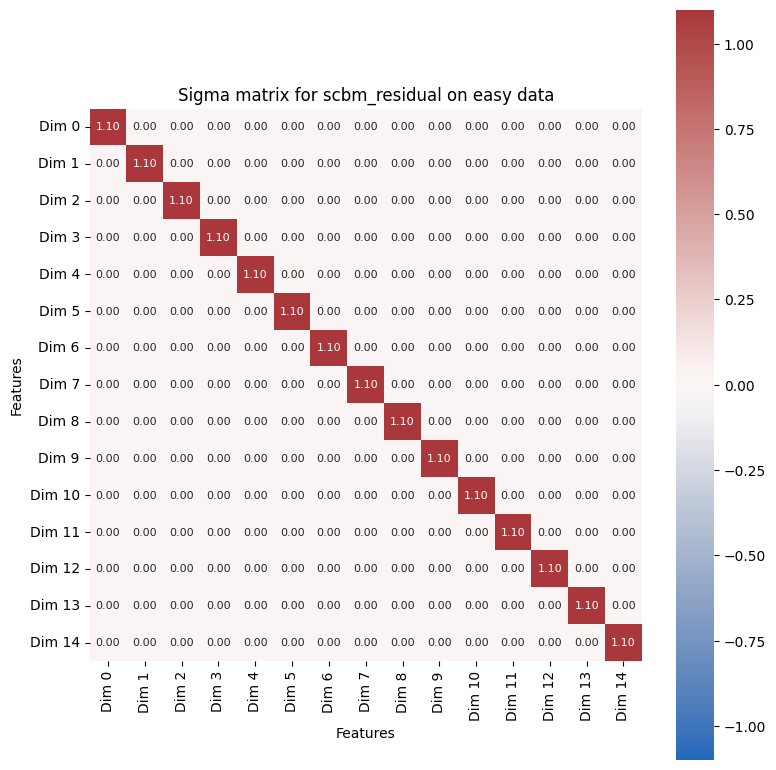

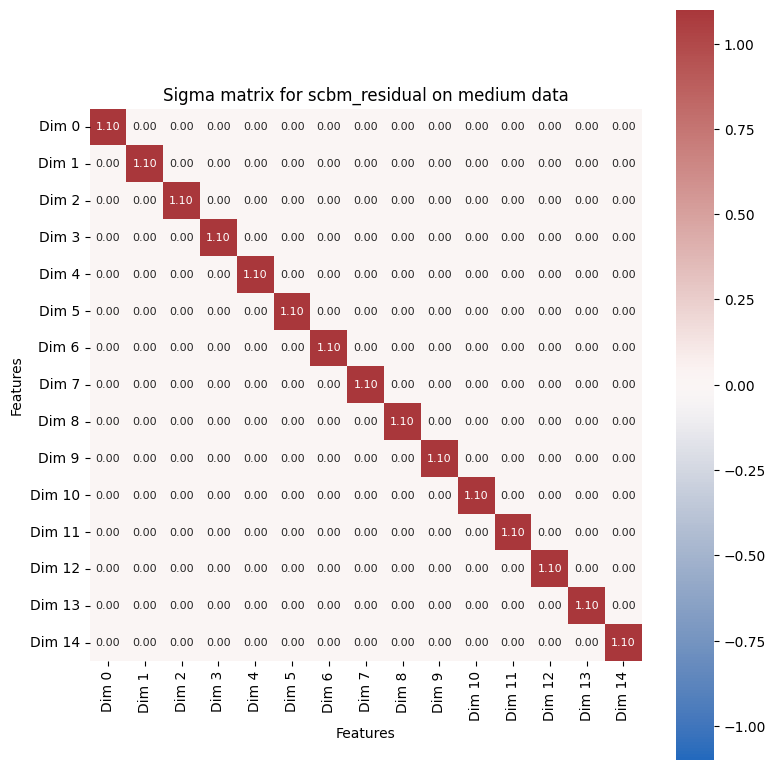

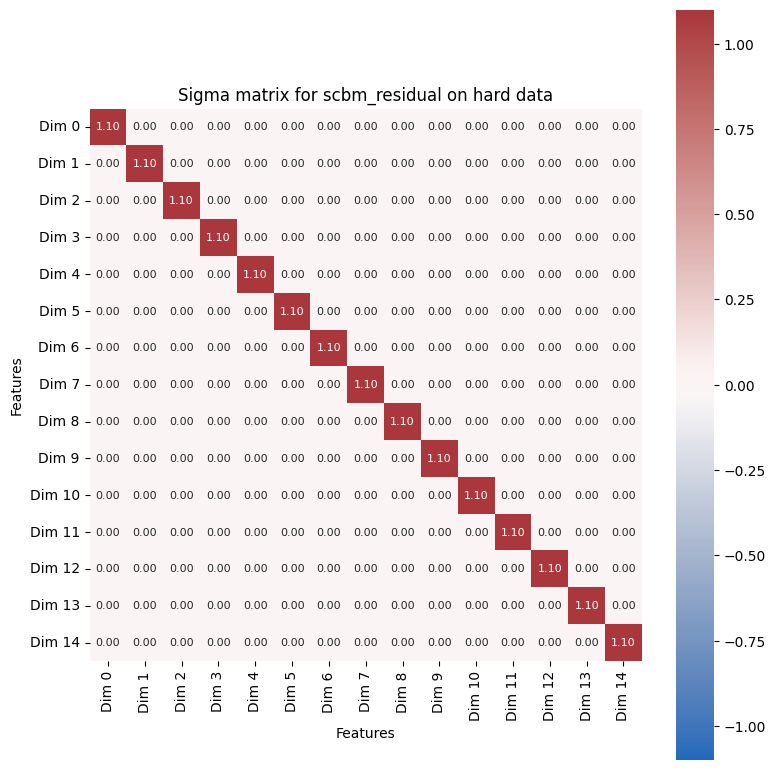

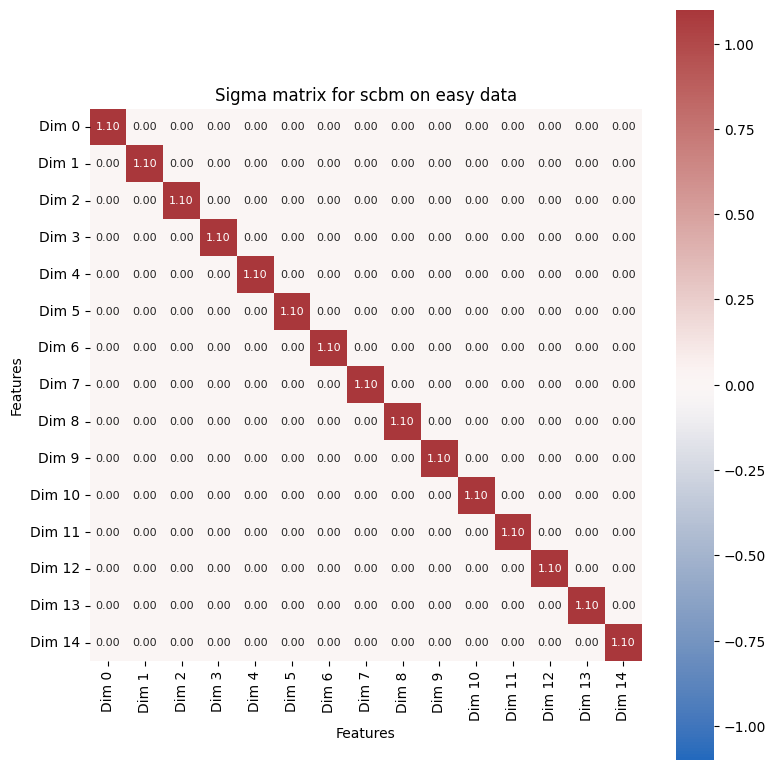

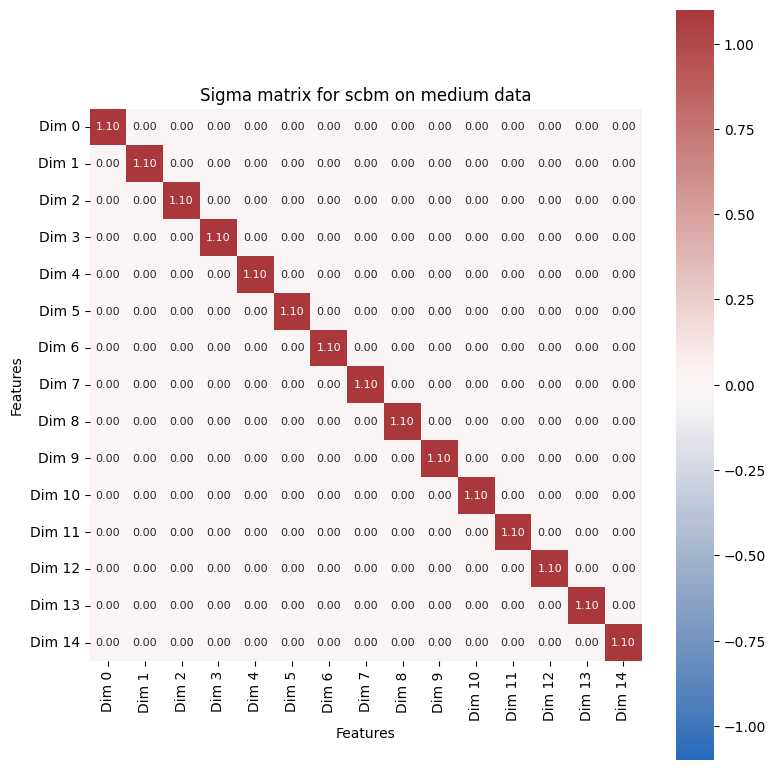

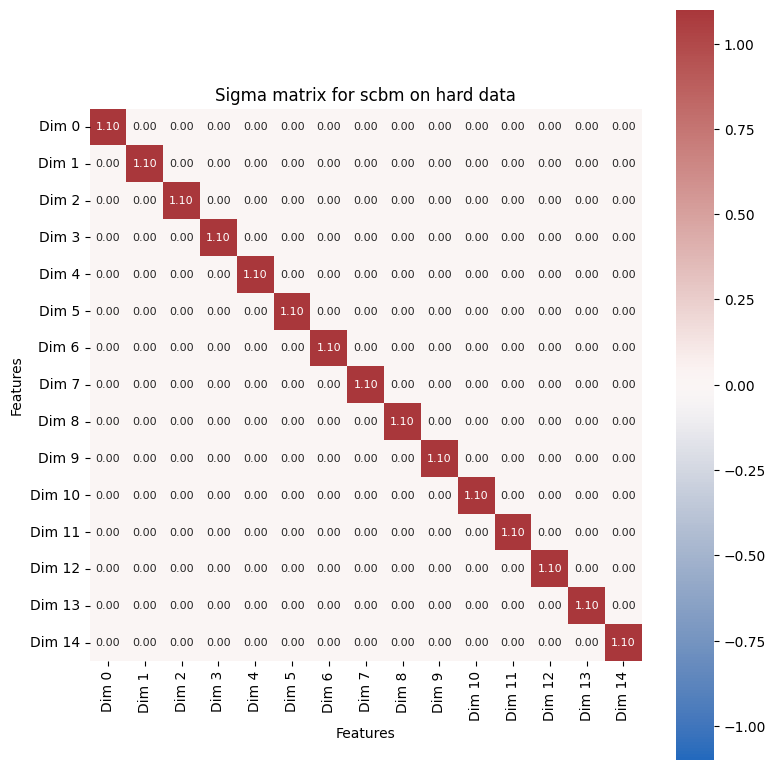

In [332]:

for model, model_path, data_difficulty in models:
    print(f"Processing model: {model}, data difficulty: {data_difficulty}")
    
    if model == "scbm_residual":
        root_model_dir = root_scbm_residual_dir
    else:
        root_model_dir = root_scbm_experiments_dir
    
    
    full_model_path = os.path.join(root_model_dir, data_difficulty, model_path)
    
    
    
    data_path = get_data_dir_path_from_model_log(full_model_path)
    
    Sigma = torch.load(os.path.join(data_root, data_difficulty, data_path, "train","Sigma.pt"))
    
    plot_sigma_heatmap(Sigma.numpy(), title=f"Sigma matrix for {model} on {data_difficulty} data", xlabel="Features", ylabel="Features")
    
    
    data_file_path = get_data_dir_path_from_model_log(full_model_path)
    full_data_path = os.path.join(data_root, data_difficulty, data_file_path)
    hidden_concepts = torch.load(os.path.join(full_data_path, "test", "residuals.pt"))
    w_hid = torch.load(os.path.join(full_data_path, "test", "w_hid.pt"))
    
    relevant = np.where(np.abs(w_hid) > 1e-8)[0]
    
    hidden_concepts_relevant = hidden_concepts[:, relevant]
    
    # Model outputs
    if model == "scbm_residual":
        residuals_sample_mean = torch.load(os.path.join(full_model_path, "residuals_sample_mean.pt"))
        
        
        residuals_sample_mean_column = [f"residuals_sample_mean_{i}" for i in range(residuals_sample_mean.shape[1])]
        hidden_concepts_column = [f"hidden_concept_{i}" for i in range(hidden_concepts.shape[1])]
        
        df = pd.concat(
            [
                pd.DataFrame(
                    residuals_sample_mean.numpy(),
                    columns=residuals_sample_mean_column,
                ),
                pd.DataFrame(
                    hidden_concepts_relevant.numpy(),
                    columns=[hidden_concepts_column[i] for i in relevant],
                ),
            ],
            axis=1,
        )
        
        df = df.iloc[:500, :]
        save_dir = os.path.join("experiments", "scbm_residual", "synthetic_res_scbm", data_difficulty, "analysis_csv", model_path)
        os.makedirs(save_dir, exist_ok=True)
        save_file = os.path.join(save_dir, "preds_sample_true_residuals.csv")
        df.to_csv(save_file, index=False)
        df.head()
        
    






Processing model: scbm_residual, data difficulty: easy
mu_res shape: torch.Size([10000, 5]), hidden_concepts_relevant shape: torch.Size([10000, 5])
Processing model: scbm_residual, data difficulty: hard
mu_res shape: torch.Size([10000, 5]), hidden_concepts_relevant shape: torch.Size([10000, 5])


/var/folders/wb/9whmmh7s5bvf174ppr2jwprr0000gn/T/ipykernel_64942/3590887783.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  relevant = np.where(np.abs(w_hid) > 1e-8)[0]
/var/folders/wb/9whmmh7s5bvf174ppr2jwprr0000gn/T/ipykernel_64942/3590887783.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  relevant = np.where(np.abs(w_hid) > 1e-8)[0]


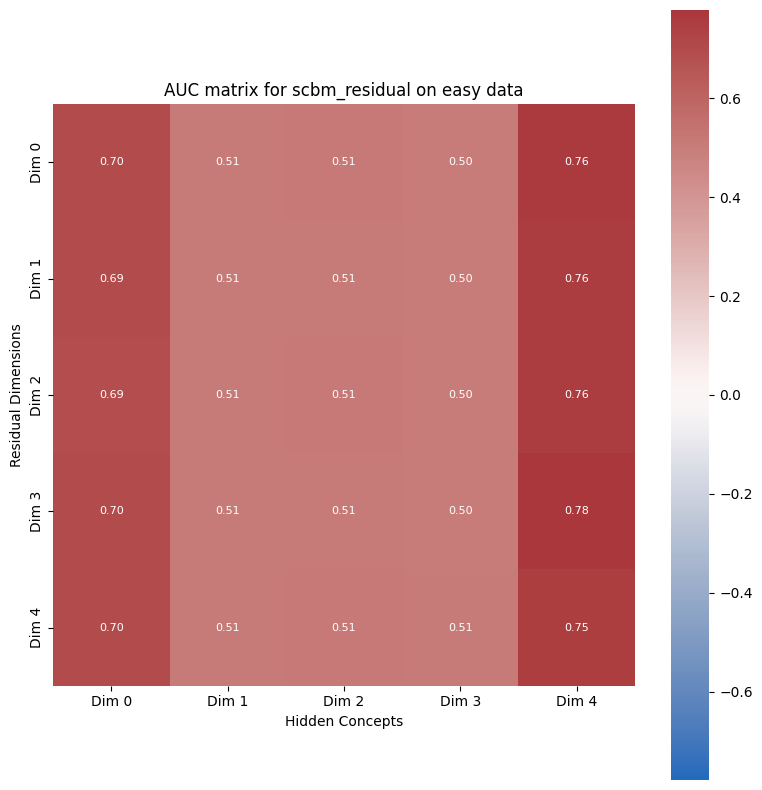

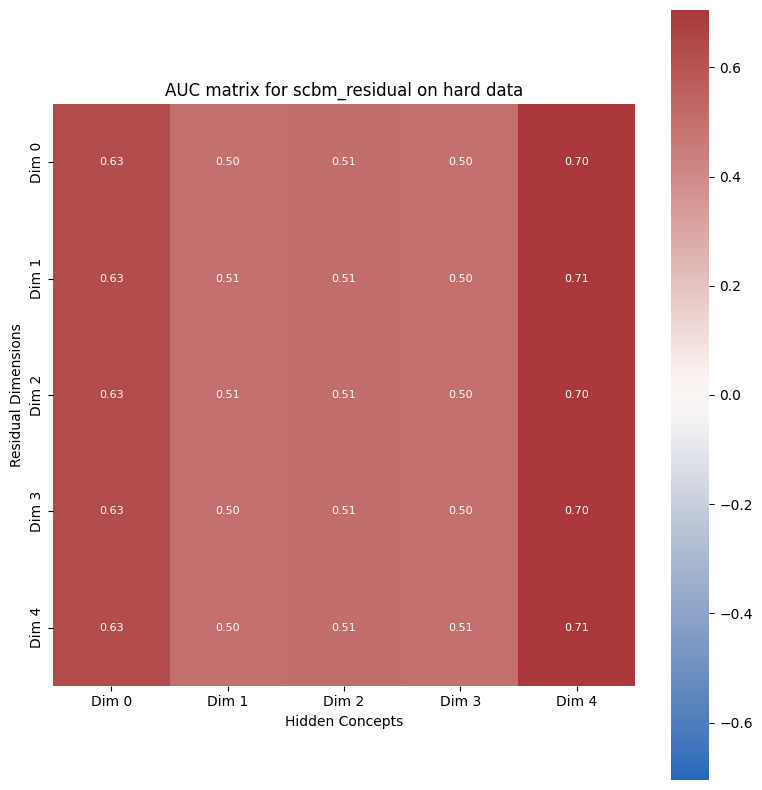

In [333]:

for model, model_path, data_difficulty in models:
    if model == "scbm_residual" and (data_difficulty == "easy" or data_difficulty == "hard"):
        print(f"Processing model: {model}, data difficulty: {data_difficulty}")
    
        full_model_path = os.path.join(root_scbm_residual_dir, data_difficulty, model_path)
    
        data_file_path = get_data_dir_path_from_model_log(full_model_path)
        full_data_path = os.path.join(data_root, data_difficulty, data_file_path)
        hidden_concepts = torch.load(os.path.join(full_data_path, "test", "residuals.pt"))
        w_hid = torch.load(os.path.join(full_data_path, "test", "w_hid.pt"))
        
        relevant = np.where(np.abs(w_hid) > 1e-8)[0]
        
        hidden_concepts_relevant = hidden_concepts[:, relevant]
        hidden_concepts_relevant = hidden_concepts
        
        mu_res = torch.load(os.path.join(full_model_path, "res_mu.pt"))
        
        print(f"mu_res shape: {mu_res.shape}, hidden_concepts_relevant shape: {hidden_concepts_relevant.shape}")
        
        auc_matrix = residual_mu_hidden_auc(mu_res, hidden_concepts_relevant)
        
        plot_sigma_heatmap(auc_matrix, title=f"AUC matrix for {model} on {data_difficulty} data", xlabel="Hidden Concepts", ylabel="Residual Dimensions")

In [334]:
for model, model_path, data_difficulty in models:
    if model == "scbm":
        continue
    print(f"Analyzing model: {model}, data difficulty: {data_difficulty}\n")
    
    # Test metrics
    metrics = test_metrics(model, model_path, data_difficulty)
    print(f"Test metrics: {metrics}")
    
    
    
    
    # Load data
    full_model_path = os.path.join(root_scbm_residual_dir, data_difficulty, model_path)
    data_path = get_data_dir_path_from_model_log(full_model_path)
    full_data_path = os.path.join(data_root, data_difficulty, data_path)
    w_hid = torch.load(os.path.join(full_data_path, "test", "w_hid.pt"))
    x = torch.load(os.path.join(full_data_path, "test", "x.pt"))
    print(f"num samples: {x.shape[0]}, num features: {x.shape[1]}")
    print(f"w_hid: {w_hid}")
    
    
    # Load csv with model predictions and true hidden concepts
    save_dir = os.path.join("experiments", "scbm_residual", "synthetic_res_scbm", data_difficulty, "analysis_csv", model_path)
    save_file = os.path.join(save_dir, "preds_sample_true_residuals.csv")
    df = pd.read_csv(save_file)
    residual_cols = [c for c in df.columns if "residual" in c and "mean" in c]
    hidden_cols = [c for c in df.columns if "hidden_concept" in c]
    
    all_pairwise_auc, best_axis_aligned = axis_aligned_recovery(df, residual_cols, hidden_cols)
    
    print(f"Model: {model}, Data difficulty: {data_difficulty}")
    print("Best axis-aligned recovery:")
    print(best_axis_aligned[["hidden_concept", "residual", "best_auc", "direction"]])
    print("-" * 50)


    

Analyzing model: scbm_residual, data difficulty: easy

Test metrics: {'y_accuracy': 0.881, 'c_accuracy': 0.937, 'c_auc': 0.983}
num samples: 10000, num features: 100
w_hid: tensor([ 0.5466,  0.0000,  0.0000,  0.0000, -0.8374])
Model: scbm_residual, Data difficulty: easy
Best axis-aligned recovery:
     hidden_concept                 residual  best_auc direction
0  hidden_concept_4  residuals_sample_mean_3  0.801941  negative
1  hidden_concept_0  residuals_sample_mean_3  0.702568  positive
--------------------------------------------------
Analyzing model: scbm_residual, data difficulty: medium

Test metrics: {'y_accuracy': 0.73, 'c_accuracy': 0.795, 'c_auc': 0.867}
num samples: 10000, num features: 100
w_hid: tensor([ 0.5466,  0.0000,  0.0000,  0.0000, -0.8374])
Model: scbm_residual, Data difficulty: medium
Best axis-aligned recovery:
     hidden_concept                 residual  best_auc direction
0  hidden_concept_4  residuals_sample_mean_3  0.715431  negative
1  hidden_concept_0  re

Running distributed recovery for model: scbm_residual, data difficulty: easy
num samples: 10000, num features: 100
w_hid: tensor([ 0.5466,  0.0000,  0.0000,  0.0000, -0.8374])
Metrics for hidden_concept_0: 0.653, AUC: 0.720, F1: 0.644


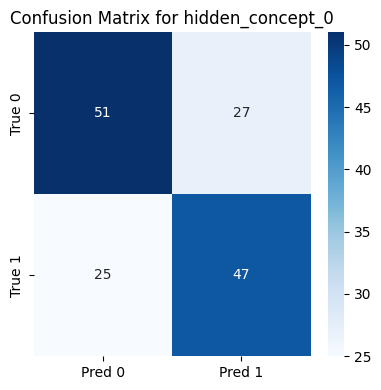

Metrics for hidden_concept_4: 0.760, AUC: 0.841, F1: 0.750


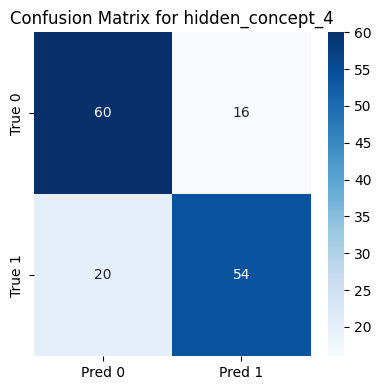

Running distributed recovery for model: scbm_residual, data difficulty: medium
num samples: 10000, num features: 100
w_hid: tensor([ 0.5466,  0.0000,  0.0000,  0.0000, -0.8374])
Metrics for hidden_concept_0: 0.653, AUC: 0.720, F1: 0.644


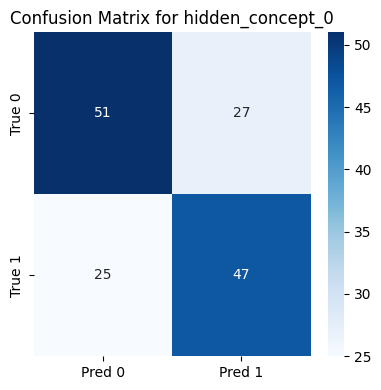

Metrics for hidden_concept_4: 0.760, AUC: 0.841, F1: 0.750


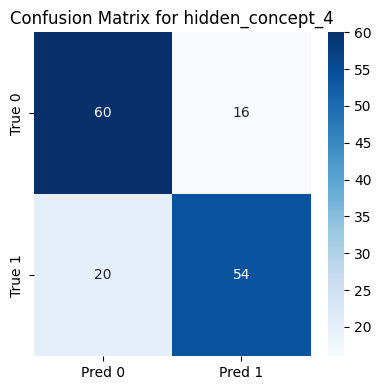

Running distributed recovery for model: scbm_residual, data difficulty: hard
num samples: 10000, num features: 100
w_hid: tensor([ 0.5466,  0.0000,  0.0000,  0.0000, -0.8374])
Metrics for hidden_concept_0: 0.653, AUC: 0.720, F1: 0.644


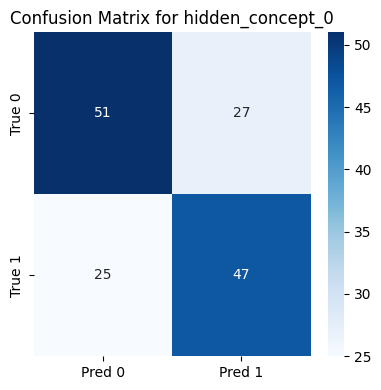

Metrics for hidden_concept_4: 0.760, AUC: 0.841, F1: 0.750


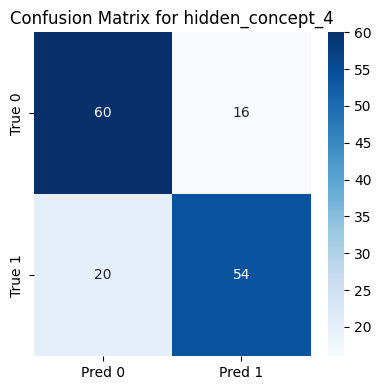

In [335]:
for model, model_path, data_difficulty in models:
    if model == "scbm":
        continue
    print(f"Running distributed recovery for model: {model}, data difficulty: {data_difficulty}")
    # Load data
    full_model_path = os.path.join(root_scbm_residual_dir, data_difficulty, model_path)
    data_path = get_data_dir_path_from_model_log(full_model_path)
    full_data_path = os.path.join(data_root, data_difficulty, data_path)
    w_hid = torch.load(os.path.join(full_data_path, "test", "w_hid.pt"))
    x = torch.load(os.path.join(full_data_path, "test", "x.pt"))
    print(f"num samples: {x.shape[0]}, num features: {x.shape[1]}")
    print(f"w_hid: {w_hid}")
    
    
    # Load csv with model predictions and true hidden concepts
    save_dir = os.path.join("experiments", "scbm_residual", "synthetic_res_scbm", data_difficulty, "analysis_csv", model_path)
    save_file = os.path.join(save_dir, "preds_sample_true_residuals.csv")
    df = pd.read_csv(save_file)
    residual_cols = [c for c in df.columns if "residual" in c and "mean" in c]
    hidden_cols = [c for c in df.columns if "hidden_concept" in c]
    
    df = pd.read_csv("experiments/scbm_residual/synthetic_res_scbm/easy/analysis_csv/alpha_1.0_beta_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_200_epochs_2026-06-04_17-42-45_ac44c/preds_sample_true_residuals.csv")
    distributed_recovery(df)

----

# Independent covariance experiment



In [336]:
scbm_experiment_dir = os.path.join("experiments", "scbm", "synthetic_res_scbm")
scbm_res_experiment_dir = os.path.join("experiments", "scbm_residual", "synthetic_res_scbm")

models = [#("scbm", "alpha_1.0_beta_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_200_epochs_2026-06-02_16-26-50_303d0"),
 ("scbm_residual", "alpha_1.0_beta_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_200_epochs_2026-06-02_16-22-14_ddf41")]


for model, model_path in models:
    metrics = test_metrics(model, model_path)
    print(f"Model: {model}")
    print(f"Test Metrics: {metrics}")



TypeError: test_metrics() missing 1 required positional argument: 'data_difficulty'

### Dataset

w_hid: tensor([-0.5824,  0.0000,  0.0000,  0.0000, -0.8129])


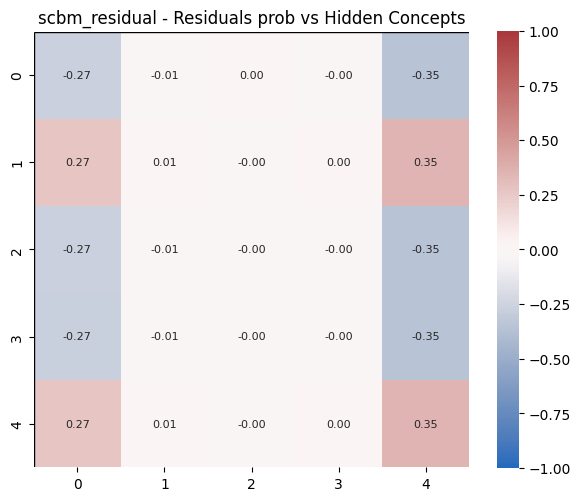

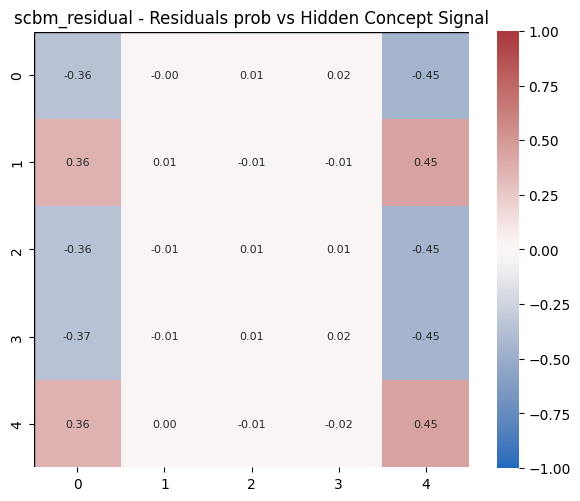

In [ ]:
data_root = "datasets/synthetic_res_scbm"

i = 0
for model, model_path in models:
    if i == 1:
        break
    
    # Get dataset info
    data_path = "cluster_a_1.0_b_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_r_sparsity_0.5_c_sparsity_0.3_sigmax_0.5_seed_0_v2"
    full_data_path = os.path.join(data_root, data_path)
    concept_signal = torch.load(os.path.join(full_data_path, "test","concept_signal.pt"))
    hidden_concept_signal = torch.load(os.path.join(full_data_path, "test","residual_signal.pt"))
    hidden_concepts = torch.load(os.path.join(full_data_path, "test","residuals.pt"))
    

    # Model outputs
    full_model_path = os.path.join("experiments", model, "synthetic_res_scbm", model_path)
    residuals_pred_probs_mean = torch.load(os.path.join(full_model_path, "residuals_pred_probs_mean.pt"))
    
    
    corr_binary = corr_matrix(residuals_pred_probs_mean, hidden_concepts)

    corr_signal = corr_matrix(residuals_pred_probs_mean, hidden_concept_signal)

    title_binary = f"{model} - Residuals prob vs Hidden Concepts"
    title_signal = f"{model} - Residuals prob vs Hidden Concept Signal"

    
    labels = [i for i in range(corr_binary.shape[0])]
    
    
    w_hid = torch.load(os.path.join(full_data_path, "test", "w_hid.pt"))
    print(f"w_hid: {w_hid}")
    
    plot_sigma_heatmap(corr_binary.numpy(), obs_dim=0, labels=labels, title=title_binary,
                       vmax=1.0, vmin=-1.0, figsize=(6,5), cmap="vlag")
    
    plot_sigma_heatmap(corr_signal.numpy(), obs_dim=0, labels=labels, title=title_signal,
                       vmax=1.0, vmin=-1.0, figsize=(6,5), cmap="vlag")
    
    
    i += 1
    


In [ ]:
i = 0
for model, model_path in models:
    if i == 1:
        break
    
    # Get dataset info
    data_path = "cluster_a_1.0_b_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_r_sparsity_0.5_c_sparsity_0.3_sigmax_0.5_seed_0_v2"
    full_data_path = os.path.join(data_root, data_path)
    concept_signal = torch.load(os.path.join(full_data_path, "test", "concept_signal.pt"))
    hidden_concept_signal = torch.load(os.path.join(full_data_path, "test", "residual_signal.pt"))
    hidden_concepts = torch.load(os.path.join(full_data_path, "test", "residuals.pt"))
    
    # Model outputs
    full_model_path = os.path.join("experiments", model, "synthetic_res_scbm", model_path)
    residuals_pred_probs_mean = torch.load(os.path.join(full_model_path, "residuals_pred_probs_mean.pt"))

    residuals_pred_probs_mean_column = [f"residuals_pred_prob_{i}" for i in range(residuals_pred_probs_mean.shape[1])]
    hidden_concept_signal_column = [f"hidden_concept_signal_{i}" for i in range(hidden_concept_signal.shape[1])]
    

    
    df = pd.concat(
        [
            pd.DataFrame(
                residuals_pred_probs_mean.numpy(),
                columns=residuals_pred_probs_mean_column,
            ),
            pd.DataFrame(
                hidden_concept_signal.numpy(),
                columns=hidden_concept_signal_column,
            ),
        ],
        axis=1,
    )
    
    df = df.iloc[:500, :]
    save_dir = os.path.join("experiments", "scbm_residual", "synthetic_res_scbm", "analysis_csv", model_path)
    os.makedirs(save_dir, exist_ok=True)
    save_file = os.path.join(save_dir, "preds_probs_true_signal_residuals.csv")
    df.to_csv(save_file, index=False)
    df.head()


### Using the binarized residual channel directly

In [ ]:
i = 0
for model, model_path in models:
    if i == 1:
        break
    
    # Get dataset info
    data_path = "cluster_a_1.0_b_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_r_sparsity_0.5_c_sparsity_0.3_sigmax_0.5_seed_0_v2"
    full_data_path = os.path.join(data_root, data_path)
    concept_signal = torch.load(os.path.join(full_data_path, "test", "concept_signal.pt"))
    hidden_concept_signal = torch.load(os.path.join(full_data_path, "test", "residual_signal.pt"))
    hidden_concepts = torch.load(os.path.join(full_data_path, "test", "residuals.pt"))
    w_hid = torch.load(os.path.join(full_data_path, "test", "w_hid.pt"))
    
    relevant = np.where(np.abs(w_hid) > 1e-8)[0]
    
    hidden_concepts_relevant = hidden_concepts[:, relevant]
    
    # Model outputs
    full_model_path = os.path.join("experiments", model, "synthetic_res_scbm", model_path)
    residuals_pred_probs_mean = torch.load(os.path.join(full_model_path, "residuals_pred_probs_mean.pt"))
    residuals_sample_mean = torch.load(os.path.join(full_model_path, "residuals_sample_mean.pt"))
    
    
    residuals_pred_probs_mean_column = [f"residuals_pred_prob_{i}" for i in range(residuals_pred_probs_mean.shape[1])]
    hidden_concept_signal_column = [f"hidden_concept_signal_{i}" for i in range(hidden_concept_signal.shape[1])]
    residuals_sample_mean_column = [f"residuals_sample_mean_{i}" for i in range(residuals_sample_mean.shape[1])]
    hidden_concepts_column = [f"hidden_concept_{i}" for i in range(hidden_concepts.shape[1])]
    
    df = pd.concat(
        [
            pd.DataFrame(
                residuals_sample_mean.numpy(),
                columns=residuals_sample_mean_column,
            ),
            pd.DataFrame(
                hidden_concepts_relevant.numpy(),
                columns=[hidden_concepts_column[i] for i in relevant],
            ),
        ],
        axis=1,
    )
    
    df = df.iloc[:500, :]
    save_dir = os.path.join("experiments", "scbm_residual", "synthetic_res_scbm", "analysis_csv", model_path)
    os.makedirs(save_dir, exist_ok=True)
    save_file = os.path.join(save_dir, "preds_sample_true_residuals.csv")
    df.to_csv(save_file, index=False)
    df.head()


/var/folders/wb/9whmmh7s5bvf174ppr2jwprr0000gn/T/ipykernel_64942/2362507443.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  relevant = np.where(np.abs(w_hid) > 1e-8)[0]


In [ ]:
import pandas as pd
import numpy as np

from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

model_path = "alpha_1.0_beta_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_200_epochs_2026-06-02_16-22-14_ddf41"
# -------------------------
# Load data
# -------------------------
save_dir = os.path.join("experiments", "scbm_residual", "synthetic_res_scbm", "analysis_csv", model_path)
save_file = os.path.join(save_dir, "preds_sample_true_residuals.csv")
df = pd.read_csv(save_file)

residual_cols = [c for c in df.columns if "residual" in c and "mean" in c]
hidden_cols = [c for c in df.columns if "hidden_concept" in c]

print("Residual columns:", residual_cols)
print("Hidden concept columns:", hidden_cols)


# -------------------------
# 1. Axis-aligned recovery
# -------------------------
def axis_aligned_recovery(df, residual_cols, hidden_cols):
    """
    For each hidden concept h_k, find the residual dimension r_j
    that best recovers it using ROC-AUC.

    Also checks the flipped direction 1 - r_j, because a residual
    may encode absence of a hidden concept.
    """
    rows = []

    for h_col in hidden_cols:
        y = df[h_col].values.astype(int)

        for r_col in residual_cols:
            r = df[r_col].values.astype(float)

            auc_pos = roc_auc_score(y, r)
            auc_neg = roc_auc_score(y, 1.0 - r)

            if auc_pos >= auc_neg:
                best_auc = auc_pos
                direction = "positive"
            else:
                best_auc = auc_neg
                direction = "negative"

            rows.append({
                "hidden_concept": h_col,
                "residual": r_col,
                "auc_positive": auc_pos,
                "auc_negative": auc_neg,
                "best_auc": best_auc,
                "direction": direction,
            })

    result = pd.DataFrame(rows)

    best_per_hidden = (
        result
        .sort_values("best_auc", ascending=False)
        .groupby("hidden_concept")
        .head(1)
        .reset_index(drop=True)
    )

    return result, best_per_hidden


all_pairwise_auc, best_axis_aligned = axis_aligned_recovery(
    df,
    residual_cols,
    hidden_cols,
)

print("\nBest axis-aligned recovery per hidden concept:")
print(best_axis_aligned)

print("\nFull pairwise residual-hidden ROC-AUC table:")
print(all_pairwise_auc.sort_values(["hidden_concept", "best_auc"], ascending=[True, False]))

Residual columns: ['residuals_sample_mean_0', 'residuals_sample_mean_1', 'residuals_sample_mean_2', 'residuals_sample_mean_3', 'residuals_sample_mean_4']
Hidden concept columns: ['hidden_concept_0', 'hidden_concept_4']

Best axis-aligned recovery per hidden concept:
     hidden_concept                 residual  auc_positive  auc_negative  \
0  hidden_concept_4  residuals_sample_mean_2      0.301549      0.698451   
1  hidden_concept_0  residuals_sample_mean_4      0.667949      0.332051   

   best_auc direction  
0  0.698451  negative  
1  0.667949  positive  

Full pairwise residual-hidden ROC-AUC table:
     hidden_concept                 residual  auc_positive  auc_negative  \
4  hidden_concept_0  residuals_sample_mean_4      0.667949      0.332051   
1  hidden_concept_0  residuals_sample_mean_1      0.664342      0.335658   
0  hidden_concept_0  residuals_sample_mean_0      0.336003      0.663997   
2  hidden_concept_0  residuals_sample_mean_2      0.336836      0.663164   
3  hid

### Cluster residual probs

In [ ]:
model = "alpha_1.0_beta_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_200_epochs_2026-06-02_16-22-14_ddf41"
model_type = "scbm_residual"

data_path = "cluster_a_1.0_b_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_r_sparsity_0.5_c_sparsity_0.3_sigmax_0.5_seed_0_v2"
full_data_path = os.path.join(data_root, data_path)

w_hid = torch.load(os.path.join(full_data_path, "test", "w_hid.pt"))
H_true = torch.load(os.path.join(full_data_path, "test", "residuals.pt"))

residuals_pred_probs_mean = torch.load(os.path.join("experiments", model_type, "synthetic_res_scbm", model, "residuals_pred_probs_mean.pt"))



In [ ]:
avg_activation_hid_concepts = H_true.mean(dim=0)
avg_activation_hid_concepts


tensor([0.5056, 0.4849, 0.5005, 0.5001, 0.5082])

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

def summarize_clusters_by_hidden_concepts(R_pred, H_true, w_hid=None, n_clusters=10, seed=0):
    relevant = np.where(np.abs(w_hid) > 1e-8)[0]
    print(f"Globally relevant hidden concepts {relevant}")
    if hasattr(R_pred, "detach"):
        R_pred = R_pred.detach().cpu().numpy()
    if hasattr(H_true, "detach"):
        H_true = H_true.detach().cpu().numpy()
    if w_hid is not None and hasattr(w_hid, "detach"):
        w_hid = w_hid.detach().cpu().numpy()

    kmeans = KMeans(n_clusters=n_clusters, random_state=seed, n_init="auto")
    cluster_ids = kmeans.fit_predict(R_pred)

    rows = []

    for k in range(n_clusters):
        
        # Get the mean hidden concept activation for samples in this cluster
        mask = cluster_ids == k # boolean mask for samples in cluster k
        hidden_rates = H_true[mask].mean(axis=0)

        if w_hid is not None:
            # Only keep concepts that are gloablly relevant
            rates_relevant = hidden_rates[relevant]
            top_local = np.argsort(-rates_relevant)[:5]
            top_hidden = relevant[top_local]
        else:
            top_hidden = np.argsort(-hidden_rates)[:5]

        rows.append({
            "cluster": k,
            "n_samples": int(mask.sum()),
            "top_hidden_concepts": top_hidden.tolist(),
            "top_hidden_rates": hidden_rates[top_hidden].round(3).tolist(),
        })

    return pd.DataFrame(rows), cluster_ids


df_cluster, cluster_ids = summarize_clusters_by_hidden_concepts(residuals_pred_probs_mean, H_true, w_hid=w_hid, n_clusters=10, seed=0)

df_cluster.head(10)


Globally relevant hidden concepts [0 4]


/var/folders/wb/9whmmh7s5bvf174ppr2jwprr0000gn/T/ipykernel_64942/1108072590.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  relevant = np.where(np.abs(w_hid) > 1e-8)[0]


,cluster,n_samples,top_hidden_concepts,top_hidden_rates
0,0,4410,"[0, 4]","[0.3479999899864197, 0.3109999895095825]"
1,1,254,"[4, 0]","[0.574999988079071, 0.5509999990463257]"
2,2,72,"[4, 0]","[0.652999997138977, 0.5]"
3,3,110,"[0, 4]","[0.6269999742507935, 0.5]"
4,4,259,"[0, 4]","[0.5680000185966492, 0.5329999923706055]"
5,5,4467,"[4, 0]","[0.6930000185966492, 0.6460000276565552]"
6,6,92,"[0, 4]","[0.6200000047683716, 0.44600000977516174]"
7,7,129,"[0, 4]","[0.6050000190734863, 0.5889999866485596]"
8,8,82,"[0, 4]","[0.5120000243186951, 0.46299999952316284]"
9,9,125,"[4, 0]","[0.6000000238418579, 0.5360000133514404]"


### Check if datasets are identical

In [ ]:
data_root = "datasets/synthetic_res_scbm"
data1 = "cluster_a_1.0_b_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_r_sparsity_0.5_c_sparsity_0.3_sigmax_0.5_seed_0"
data2 = "cluster_a_1.0_b_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_r_sparsity_0.5_c_sparsity_0.3_sigmax_0.5_seed_0_v2"

datasets = [data1, data2]
splits = ["train", "val", "test"]

data_dict = {}

for data_dir in datasets:
    for split in splits:
        if not os.path.exists(os.path.join(data_root, data_dir, split)):
            print(f"Directory not found: {os.path.join(data_root, data_dir, split)}")
            continue
        print(f"Loading data from {data_dir} for split {split}")
        x_path = os.path.join(data_root, data_dir, split, "x.pt")
        print(f"Loading x from {x_path}")
        y_path = os.path.join(data_root, data_dir, split, "y.pt")
        s_path = os.path.join(data_root, data_dir, split, "s.pt")
        x = torch.load(x_path)
        y = torch.load(y_path)
        s = torch.load(s_path)
        print(x.shape, y.shape, s.shape)
        data_dict[(data_dir, split)] = (x, y, s)
        
for split in splits:
    x1, y1, s1 = data_dict[(data1, split)]
    x2, y2, s2 = data_dict[(data2, split)]
    # Check if x1 and x2 are the same
    if torch.allclose(x1, x2):
        print(f"x tensors are the same for split {split}")
    else:
        print(f"x tensors differ for split {split}")
    # Check if y1 and y2 are the same
    if torch.allclose(y1, y2):
        print(f"y tensors are the same for split {split}")
    else:
        print(f"y tensors differ for split {split}")
    # Check if s1 and s2 are the same
    if torch.allclose(s1, s2):
        print(f"s tensors are the same for split {split}")
    else:
        print(f"s tensors differ for split {split}")
    


Loading data from cluster_a_1.0_b_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_r_sparsity_0.5_c_sparsity_0.3_sigmax_0.5_seed_0 for split train
Loading x from datasets/synthetic_res_scbm/cluster_a_1.0_b_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_r_sparsity_0.5_c_sparsity_0.3_sigmax_0.5_seed_0/train/x.pt
torch.Size([30000, 100]) torch.Size([30000]) torch.Size([30000])
Loading data from cluster_a_1.0_b_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_r_sparsity_0.5_c_sparsity_0.3_sigmax_0.5_seed_0 for split val
Loading x from datasets/synthetic_res_scbm/cluster_a_1.0_b_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_r_sparsity_0.5_c_sparsity_0.3_sigmax_0.5_seed_0/val/x.pt
torch.Size([10000, 100]) torch.Size([10000]) torch.Size([10000])
Loading data from cluster_a_1.0_b_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_r_sparsity_0.5_c_sparsity_0.3_sigmax_0.5_seed_0 for split test
Loading x from datasets/synthetic_res_scbm/cluster_a_1.0_b_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_r_sparsity_0.5_c_sparsity_0.3_sigmax_0.5_seed_0/test/x.pt
torch.Size([10000, 100]) torch.Size(